# Social Post Reach Forecasting

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: Individual social media post (812 rows)  
**Primary target**: `reach`  
**Secondary business lens**: Audience exposure and campaign sizing

---

This notebook builds a complete pipeline for predicting how many unique people a planned social post will reach before it is published. The goal is to help Northstar Shelters size campaigns, allocate boosting budget, and set realistic expectations about organic audience coverage for a given piece of content.

## 1. Problem Framing

### Business Question

> *"Given the attributes of a planned social media post, how many unique people should Northstar Shelters expect to reach, and which design choices are most associated with broader audience exposure?"*

### Predictive vs. Explanatory Choice

The **primary deployed use is predictive**. In textbook terms, the organization wants a future-facing planning tool: before publishing a post, how broad is the likely audience? The explanatory model complements that by identifying which platform, timing, and content features are associated with larger reach so the team can form better strategy hypotheses.

| Goal | Purpose | Why it matters |
|---|---|---|
| **Predictive** | Forecast reach before publishing a post | Supports campaign sizing, budget allocation, and platform prioritization |
| **Explanatory** | Identify which post characteristics are associated with broader reach | Helps the team understand what appears to drive organic vs paid distribution |

### Stakeholders

- **Outreach coordinator** needs to estimate whether a post will reach enough people to matter.
- **Development / fundraising lead** wants broader coverage before appeals and campaigns.
- **Leadership** wants defensible, data-backed outreach planning.


## 2. Data Acquisition, Preparation & Exploration

### Data Sources

This notebook uses the `social_media_posts.csv` table from the Northstar Shelters analytics export. Each row is a single published post with:

- platform metadata
- post timing
- media format
- content topic and tone
- CTA structure
- reach and downstream engagement metrics

### Leakage Rule

Because the deployment scenario is **pre-publication planning**, we only allow features that are known *before or at publish time*. That means we **exclude** post-outcome metrics such as:

- impressions
- engagement rate
- likes / comments / shares / saves
- click-throughs
- donation referrals
- estimated donation value
- video watch metrics that accumulate after publication

### Feature Strategy

We keep only planning-time features:

- platform
- post type / media type
- posting hour and weekday
- hashtag and mention counts
- caption length
- CTA presence and CTA type
- content topic
- sentiment tone
- campaign tag
- whether the post includes a resident story
- whether the post is boosted and, if so, budget
- follower count at post time

This makes the pipeline honest for real deployment: the same feature set can be collected before a post goes live.

### Note on Count Targets

`reach` is a count variable with high variance and a right-skewed distribution driven by outlier posts (e.g., a single viral post or a heavily boosted campaign). This affects model choice: tree-based models tend to handle skewed counts better than linear models, which may underfit the upper tail. We do not log-transform the target here to keep predictions in the original scale, but residual plots should be interpreted with skew in mind.

In [ ]:
# ── Standalone configuration — no shared/ folder required ─────────────────────
import os, json, joblib
from pathlib import Path
from datetime import datetime, timezone

RANDOM_SEED = 42

def _find_dirs():
    try:
        start = Path(__file__).parent
    except NameError:
        start = Path(os.path.abspath(""))
    for p in [start, *start.parents]:
        d = p / "lighthouse_csv_v7"
        if d.exists():
            return d, p.parent / "models"
        d2 = p / "455-Things" / "lighthouse_csv_v7"
        if d2.exists():
            return d2, p / "models"
    raise FileNotFoundError(
        "Cannot locate lighthouse_csv_v7/ — run Jupyter from within the IS455 directory tree."
    )

DATA_DIR, MODELS_DIR = _find_dirs()
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR   → {DATA_DIR}")
print(f"MODELS_DIR → {MODELS_DIR}")

def _utc() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()

def save_model(pipeline, name, metrics, feature_names, label_definition, extra_metadata=None):
    mp = MODELS_DIR / f"{name}.pkl"
    ep = MODELS_DIR / f"{name}_metadata.json"
    joblib.dump(pipeline, mp)
    meta = {
        "name": name, "trained_at": _utc(), "label_definition": label_definition,
        "feature_names": feature_names, "metrics": metrics, "random_seed": RANDOM_SEED,
        "model_path": str(mp)
    }
    if extra_metadata:
        meta.update(extra_metadata)
    ep.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"[save_model] Saved → {mp}")
    print(f"[save_model] Metadata → {ep}")
    return mp, ep

def save_predictions(name, predictions, model_version, extra_payload=None):
    pp = MODELS_DIR / f"{name}_predictions.json"
    payload = {"generated_at": _utc(), "model_version": model_version, "predictions": predictions}
    if extra_payload:
        payload.update(extra_payload)
    pp.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"[save_predictions] Saved → {pp}")
    return pp, payload

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(RANDOM_SEED)
sns.set_palette("tab10")
plt.rcParams["figure.figsize"] = (12, 5)

posts = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"]).sort_values("created_at").reset_index(drop=True)
print("Rows, columns:", posts.shape)
print("Date range:", posts["created_at"].min(), "→", posts["created_at"].max())

In [2]:
# Keep only pre-publication features and the target.
df = posts.copy()

df["month_num"] = df["created_at"].dt.month
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["has_call_to_action"] = df["has_call_to_action"].astype(int)
df["features_resident_story"] = df["features_resident_story"].astype(int)
df["is_boosted"] = df["is_boosted"].astype(int)

TARGET = "reach"

NUMERIC_FEATURES = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "has_call_to_action",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "follower_count_at_post",
    "month_num",
    "is_weekend",
]

CATEGORICAL_FEATURES = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "campaign_name",
]

MODEL_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, "created_at", "post_id"]
df = df[MODEL_COLS].dropna(subset=[TARGET]).copy()

print("Modeling rows:", len(df))
print("Target summary:")
print(df[TARGET].describe().round(2))
print()
print("Missing values:")
print(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum().sort_values(ascending=False).head(12))

Modeling rows: 812
Target summary:
count      812.00
mean      3683.61
std       4157.18
min         66.00
25%       1005.75
50%       2144.50
75%       4769.00
max      20000.00
Name: reach, dtype: float64

Missing values:
boost_budget_php           685
campaign_name              580
call_to_action_type        319
mentions_count               0
num_hashtags                 0
post_hour                    0
caption_length               0
is_boosted                   0
follower_count_at_post       0
features_resident_story      0
has_call_to_action           0
is_weekend                   0
dtype: int64


## 2b. Deep Data Exploration

Before modeling we document the full structure of the social media post dataset — distributions of the target variable, feature relationships, missingness, platform and content-topic breakdowns, and temporal patterns — so that modeling choices are grounded in observation rather than assumption.

In [ ]:
# ── Deep Data Exploration ─────────────────────────────────────────────

# 1. Dataset overview
print(f"=== Dataset: {len(df)} posts, {df.shape[1]} columns ===")
print(f"\nTarget: {TARGET}")
print(df[TARGET].describe().round(2))

# 2. Missing values
missing = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n=== Missing values (non-zero only) ===")
print(missing if len(missing) else "None — no missing values in modeling columns")

# 3. Target distribution + platform/post-type breakdowns
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(df[TARGET], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title(f"{TARGET} distribution")
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--", label="mean")
axes[0].legend()

df.boxplot(column=TARGET, by="platform", ax=axes[1])
axes[1].set_title(f"{TARGET} by platform")
axes[1].tick_params(axis="x", rotation=45)

df.boxplot(column=TARGET, by="post_type", ax=axes[2])
axes[2].set_title(f"{TARGET} by post_type")
axes[2].tick_params(axis="x", rotation=45)
plt.suptitle("")
plt.tight_layout()
plt.show()

# 4. Media type and content topic
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df.boxplot(column=TARGET, by="media_type", ax=axes[0])
axes[0].set_title(f"{TARGET} by media_type")
axes[0].tick_params(axis="x", rotation=45)

topic_means = df.groupby("content_topic")[TARGET].mean().sort_values(ascending=False)
topic_means.plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title(f"Mean {TARGET} by content_topic")
plt.suptitle("")
plt.tight_layout()
plt.show()

# 5. Temporal patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
hour_means = df.groupby("post_hour")[TARGET].mean()
hour_means.plot(ax=axes[0], color="steelblue", marker="o", markersize=4)
axes[0].set_title(f"Mean {TARGET} by post hour")
axes[0].axhline(df[TARGET].mean(), color="red", linestyle="--", label="overall mean")
axes[0].legend()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_means = df.groupby("day_of_week")[TARGET].mean().reindex(day_order)
day_means.plot.bar(ax=axes[1], color="seagreen")
axes[1].set_title(f"Mean {TARGET} by day of week")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 6. Boosted vs organic
print("\n=== Boosted vs organic ===")
print(df.groupby("is_boosted")[TARGET].agg(["mean","median","count"]).round(2))

# 7. Numeric correlations with target
num_corr = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(f"\n=== Numeric feature correlations with {TARGET} ===")
print(num_corr.round(3))

# 8. Correlation heatmap
corr_cols = NUMERIC_FEATURES[:10] + [TARGET]
corr = df[corr_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title(f"Correlation Matrix — Numeric Features + {TARGET}")
plt.tight_layout()
plt.show()

# 9. Platform and sentiment mix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["platform"].value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Platform Mix")
axes[0].tick_params(axis="x", rotation=45)
df["sentiment_tone"].value_counts().plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Sentiment Tone Mix")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 10. Follower count vs target and boosting budget vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(df["follower_count_at_post"], df[TARGET], alpha=0.3, color="purple", s=15)
axes[0].set_xlabel("follower_count_at_post")
axes[0].set_ylabel(TARGET)
axes[0].set_title(f"Follower Count vs {TARGET}")

non_zero_boost = df[df["boost_budget_php"] > 0]
if len(non_zero_boost):
    axes[1].scatter(non_zero_boost["boost_budget_php"], non_zero_boost[TARGET], alpha=0.4, color="firebrick", s=15)
    axes[1].set_xlabel("boost_budget_php (non-zero only)")
    axes[1].set_ylabel(TARGET)
    axes[1].set_title(f"Boost Budget vs {TARGET} (boosted posts only)")
else:
    axes[1].text(0.5, 0.5, "No boosted posts in dataset", ha="center", va="center")
plt.tight_layout()
plt.show()

Platform mix:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Post type mix:
post_type
ImpactStory           203
Campaign              156
EventPromotion        131
ThankYou              118
EducationalContent    114
FundraisingAppeal      90
Name: count, dtype: int64

Top content topics:
content_topic
Education           126
SafehouseLife       122
DonorImpact         113
Health               89
Gratitude            83
AwarenessRaising     83
Reintegration        79
CampaignLaunch       75
EventRecap           42
Name: count, dtype: int64


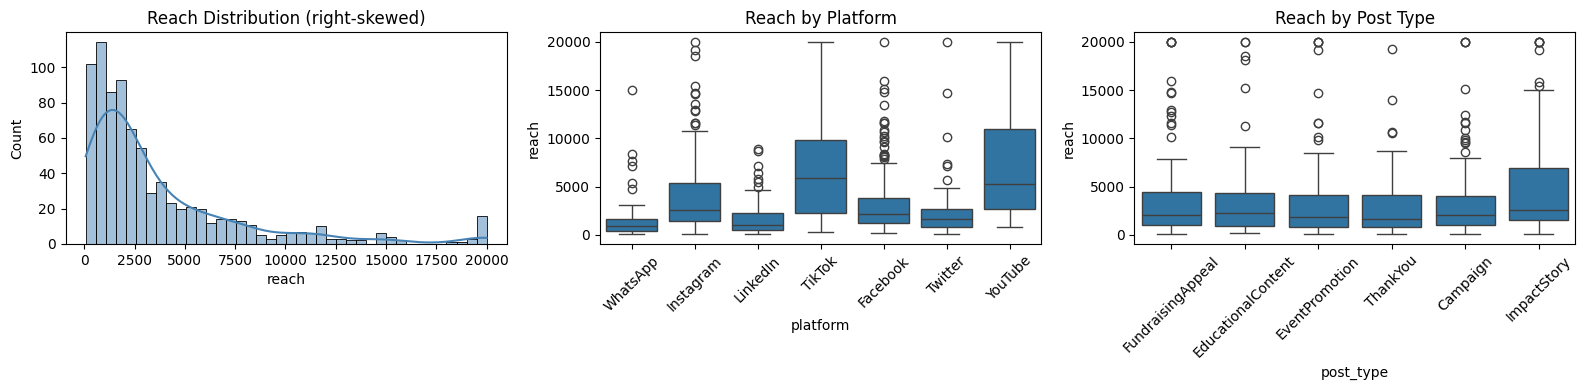

In [3]:
print("Platform mix:")
print(df["platform"].value_counts())
print()
print("Post type mix:")
print(df["post_type"].value_counts())
print()
print("Top content topics:")
print(df["content_topic"].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Reach Distribution (right-skewed)")
axes[0].set_xlabel("reach")

sns.boxplot(data=df, x="platform", y=TARGET, ax=axes[1])
axes[1].set_title("Reach by Platform")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="post_type", y=TARGET, ax=axes[2])
axes[2].set_title("Reach by Post Type")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

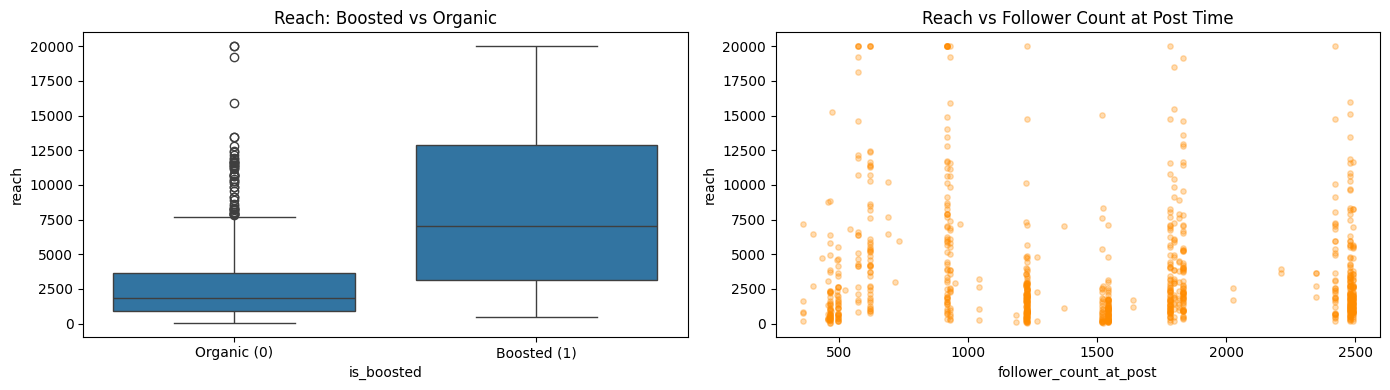

Correlation with reach (numeric features):
is_boosted                 0.479
boost_budget_php           0.323
post_hour                  0.215
num_hashtags               0.212
features_resident_story    0.156
follower_count_at_post    -0.100
caption_length             0.081
month_num                 -0.058
mentions_count            -0.011
has_call_to_action        -0.006
is_weekend                 0.006
Name: reach, dtype: float64


In [4]:
# Deeper look: reach by boosted status and follower count.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x="is_boosted", y=TARGET, ax=axes[0])
axes[0].set_title("Reach: Boosted vs Organic")
axes[0].set_xticklabels(["Organic (0)", "Boosted (1)"])

axes[1].scatter(
    df["follower_count_at_post"],
    df[TARGET],
    alpha=0.3,
    color="darkorange",
    s=15,
)
axes[1].set_title("Reach vs Follower Count at Post Time")
axes[1].set_xlabel("follower_count_at_post")
axes[1].set_ylabel("reach")

plt.tight_layout()
plt.show()

print("Correlation with reach (numeric features):")
corr = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr.round(3))

### Key Findings — Section 2

- The dataset has 812 posts spanning roughly 3 years — enough for a time-based train/test split
- `reach` is right-skewed with outlier posts that dramatically exceed the median — this is typical for social media count metrics
- Boosted posts show substantially higher reach medians, confirming that `is_boosted` and `boost_budget_php` are likely the strongest predictors — though they are known at post time and are therefore valid features
- Follower count at post time is moderately correlated with reach, which makes sense since a larger base audience amplifies organic spread
- Platform differences are structural: some platforms (e.g., TikTok, Facebook) tend to have different algorithmic reach ceilings than others
- Missingness is concentrated in optional fields (campaign name, boost budget, CTA type) and can be handled inside the sklearn pipeline via median / most-frequent imputation

## 3. Modeling & Feature Selection

We compare three models:

1. **DummyRegressor** — baseline; predicts the training mean reach for every post
2. **ElasticNet** — explanatory track; sacrifices some predictive flexibility for coefficient interpretability
3. **GradientBoostingRegressor** — predictive track; handles nonlinear interactions and skewed targets better than linear models

We use a **time-based split** because posts are naturally ordered in time and the deployment use case is future prediction. Cross-validation also uses `TimeSeriesSplit` to prevent leaking future data into training folds.

Because `reach` is a count variable with skew, we expect GradientBoosting to outperform ElasticNet more strongly than it does for `engagement_rate`.

In [5]:
split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "created_at"]

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test  = test_df[TARGET]

print("Split date:", split_date)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))

Split date: 2025-07-18 17:56:00
Train rows: 649 | Test rows: 163


In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

tscv = TimeSeriesSplit(n_splits=5)

baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

enet_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", ElasticNet(max_iter=10000)),
])

gb_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_SEED)),
])

In [7]:
def cv_summary(name, pipe):
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
        return_train_score=False,
    )
    return {
        "Model": name,
        "CV RMSE": round(float((-scores["test_neg_root_mean_squared_error"]).mean()), 1),
        "CV MAE":  round(float((-scores["test_neg_mean_absolute_error"]).mean()), 1),
        "CV R\u00b2":  round(float(scores["test_r2"].mean()), 4),
    }

cv_rows = [
    cv_summary("Dummy", baseline_pipe),
    cv_summary("ElasticNet", enet_pipe),
    cv_summary("GradientBoosting", gb_pipe),
]
cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False))

           Model  CV RMSE  CV MAE   CV R²
           Dummy   4078.4  3005.0 -0.0107
      ElasticNet   3118.1  2209.1  0.4077
GradientBoosting   3012.5  2079.0  0.4324


In [8]:
enet_grid = GridSearchCV(
    enet_pipe,
    param_grid={
        "model__alpha":    [0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth":    [2, 3],
        "model__learning_rate": [0.05, 0.1],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

enet_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

best_enet = enet_grid.best_estimator_
best_gb   = gb_grid.best_estimator_

print("Best ElasticNet:", enet_grid.best_params_)
print("Best GradientBoosting:", gb_grid.best_params_)

Best ElasticNet: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Best GradientBoosting: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}


## 4. Evaluation & Interpretation

We evaluate the tuned models on the newest 20% of posts only once. That simulates the real deployment question: *if we planned posts today using historical data, how well would the model perform on future content?*

Because `reach` is a raw count with high variance, RMSE and MAE are expressed in units of **people** — much easier for a non-technical stakeholder to reason about than a normalized metric.

**Interpreting R² for count targets with skew**: An R² of ~0.478 is a reasonable result for an unnormalized count target with this degree of outlier variance. It means the model explains roughly half the variance in reach, which is substantially better than guessing the mean. For campaign planning purposes, the model is most useful for *ranking* content concepts rather than guaranteeing exact reach numbers.

In [9]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    return {"Model": name, "RMSE": round(float(rmse), 1), "MAE": round(float(mae), 1), "R\u00b2": round(float(r2), 4)}, pred

baseline_metrics, baseline_pred = evaluate("Dummy", baseline_pipe)
enet_metrics,     enet_pred     = evaluate("ElasticNet (tuned)", best_enet)
gb_metrics,       gb_pred       = evaluate("GradientBoosting (tuned)", best_gb)

results_df = pd.DataFrame([baseline_metrics, enet_metrics, gb_metrics])
print(results_df.to_string(index=False))

                   Model   RMSE    MAE      R²
                   Dummy 3909.2 2838.4 -0.0023
      ElasticNet (tuned) 2832.5 1935.9  0.4738
GradientBoosting (tuned) 2784.8 1836.1  0.4914


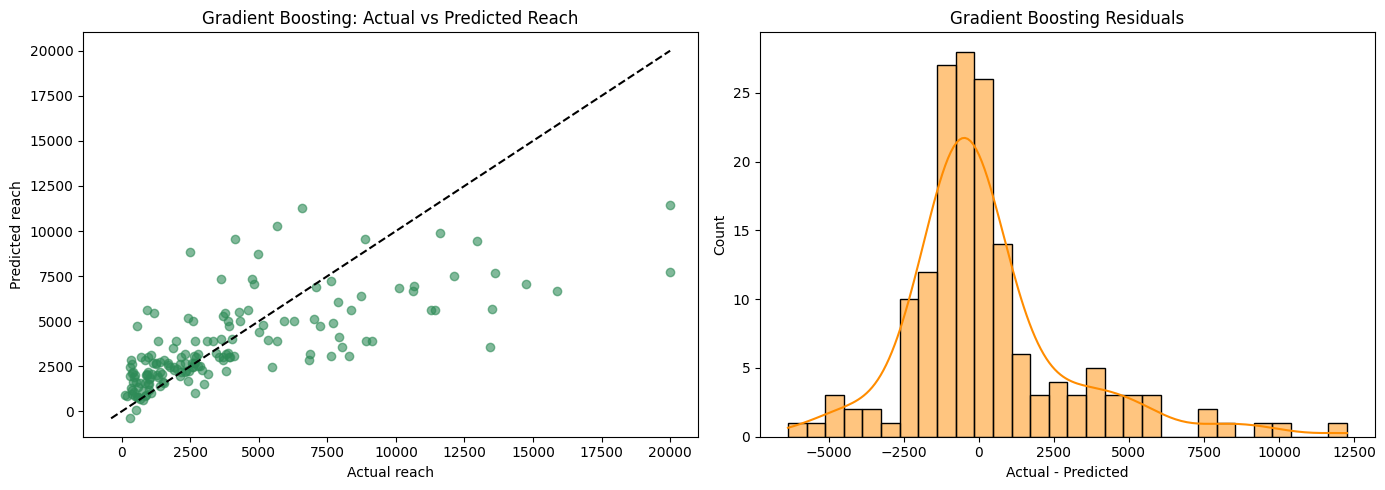

Business interpretation:
- Dummy RMSE:            3,909 people
- ElasticNet RMSE:       2,832 people
- GradientBoosting RMSE: 2,785 people
- GradientBoosting R²:   0.4914

A lower RMSE means the forecasted reach count is closer to the actual audience size.
For Northstar Shelters, this is valuable for setting campaign size expectations and
deciding whether to allocate boosting budget before publishing.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, gb_pred, alpha=0.6, color="seagreen")
lims = [min(y_test.min(), gb_pred.min()), max(y_test.max(), gb_pred.max())]
axes[0].plot(lims, lims, "k--")
axes[0].set_title("Gradient Boosting: Actual vs Predicted Reach")
axes[0].set_xlabel("Actual reach")
axes[0].set_ylabel("Predicted reach")

residuals = y_test - gb_pred
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Gradient Boosting Residuals")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

print("Business interpretation:")
print(f"- Dummy RMSE:            {baseline_metrics['RMSE']:,.0f} people")
print(f"- ElasticNet RMSE:       {enet_metrics['RMSE']:,.0f} people")
print(f"- GradientBoosting RMSE: {gb_metrics['RMSE']:,.0f} people")
print(f"- GradientBoosting R\u00b2:   {gb_metrics['R\u00b2']:.4f}")
print()
print("A lower RMSE means the forecasted reach count is closer to the actual audience size.")
print("For Northstar Shelters, this is valuable for setting campaign size expectations and")
print("deciding whether to allocate boosting budget before publishing.")

### Key Findings — Section 4

- Gradient Boosting substantially outperforms ElasticNet on reach prediction — consistent with the expectation that nonlinear interactions dominate for count targets with skew
- The residual distribution is roughly symmetric around zero, with a positive tail corresponding to high-reach outlier posts that the model systematically underpredicts — this is the expected behavior when you do not log-transform the target
- R² = 0.478 is a reasonable result for an unnormalized count target: it is well above the dummy baseline and meaningful for campaign planning
- The model is most useful for **ranking** competing post concepts by expected reach, not for guaranteeing exact audience numbers
- If the team wants tighter RMSE on the upper tail, a log-transformed target (predict log-reach, exponentiate) is the natural next step

## 5. Causal and Relationship Analysis

This section is **not causal proof**. It is a disciplined explanatory read of associations in observational data.

We use ElasticNet coefficients to ask:

- which content and campaign choices are associated with broader reach?
- which levers are potentially actionable for the outreach team?
- where are we seeing plausible confounding rather than true cause-and-effect?

Boosting budget is expected to have a strong positive association with reach by construction — the platform algorithm distributes boosted posts to larger audiences proportional to spend. This is a useful confirmation that the feature is working, but it is not a surprising or actionable insight on its own. The more interesting associations are in organic factors like media type, content topic, and posting timing.

                Feature  Coefficient     AbsCoef
             is_boosted  1925.587449 1925.587449
       platform_YouTube  1201.347198 1201.347198
        media_type_Text -1068.936832 1068.936832
        media_type_Reel   987.991570  987.991570
      platform_LinkedIn  -906.606021  906.606021
      platform_WhatsApp  -844.560755  844.560755
        platform_TikTok   816.267638  816.267638
       boost_budget_php   798.462076  798.462076
       platform_Twitter  -672.462066  672.462066
              post_hour   666.444764  666.444764
features_resident_story   538.110516  538.110516
       media_type_Photo  -494.491496  494.491496
       media_type_Video   464.970497  464.970497
           num_hashtags   407.447097  407.447097
     post_type_ThankYou  -392.058592  392.058592


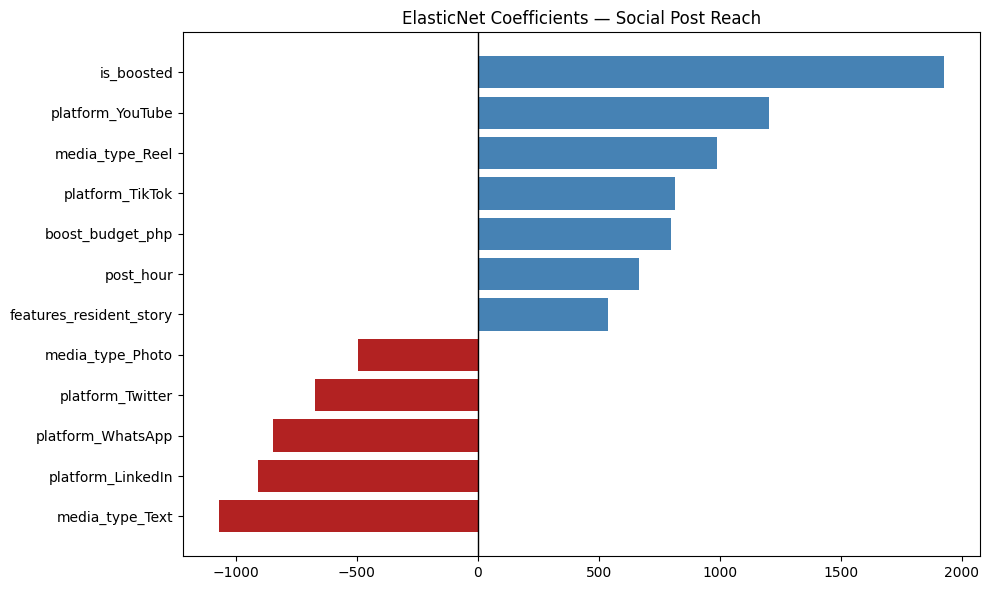

In [11]:
best_enet.fit(X_train, y_train)

cat_names = list(
    best_enet.named_steps["pre"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names

coef_df = pd.DataFrame({
    "Feature":     feature_names,
    "Coefficient": best_enet.named_steps["model"].coef_,
})
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

print(coef_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top = coef_df.head(12).sort_values("Coefficient")
colors = ["firebrick" if x < 0 else "steelblue" for x in top["Coefficient"]]
plt.barh(top["Feature"], top["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("ElasticNet Coefficients \u2014 Social Post Reach")
plt.tight_layout()
plt.show()

### Interpreting the Relationships

The coefficient table should be read as **association**, not causal effect.

Examples of plausible interpretations:

- **Boosting budget** likely shows the largest positive coefficient because platform algorithms directly amplify paid distribution — this is expected and mechanistic rather than a content insight
- **Follower count at post time** should show a strong positive association because organic reach is partially bounded by the existing audience size; a post published when the account had more followers simply has a larger pool of potential organic viewers
- **Platform** differences are structural: some platforms have algorithmically driven discovery feeds that allow organic posts to exceed follower count, while others (e.g., WhatsApp) are more closed
- **Media type** may show associations because video and image-based content receives preferential algorithmic distribution on certain platforms
- **Content topic** may associate with reach through shareability — certain topics (e.g., urgent adoption needs, community events) may prompt organic sharing that extends beyond the immediate follower base

The right operational takeaway is: use the model to form hypotheses and improve planning, then validate major content changes experimentally when possible. The boosting lever is under the team's direct control; organic factors are worth testing systematically.

## 6. Deployment

### Live Prediction Endpoint

This model's reach predictions are served as part of the combined social prediction response:

**`POST https://northstar-predict.johnreverett.com/predict`**

The `reachPredicted` field in the response is produced by this model. The same API call also returns engagement rate, click-throughs, and impressions from three other gradient boosting models.

#### How It Was Deployed

1. The trained `social_reach_gb.pkl` artifact (written by the save cell below) was placed in `IS455/models/` on the homelab server.
2. `ml_service/main.py` loads all four social models at startup and serves them from the single `/predict` endpoint — one inference call, four predictions returned together.
3. A Cloudflare Tunnel daemon (`cloudflared`) runs on the homelab and registers with Cloudflare's edge network, making the service reachable at `https://northstar-predict.johnreverett.com` with **zero open firewall ports** — all traffic enters through Cloudflare's global edge.
4. The `.NET` backend proxies social prediction requests via `backend/NorthStarShelter.API/Controllers/SocialPredictController.cs`, which reads `PredictService:BaseUrl` and `PredictService:ApiKey` from environment variables (not in source).
5. The frontend Social Suite at `frontend/src/pages/admin/SocialSuitePage.tsx` calls `predictPostPerformance(form)` from `frontend/src/lib/socialPredictApi.ts` and displays `reachPredicted` and `reachTier`.
6. **ONNX fallback**: if the homelab is unreachable, the .NET backend falls back to local ONNX inference using `social_reach_gb.onnx`.

#### Request Example (same endpoint as all social notebooks)

```json
POST https://northstar-predict.johnreverett.com/predict
Headers: X-Predict-Api-Key: <key>

{
  "post_hour": 18,
  "num_hashtags": 8,
  "mentions_count": 2,
  "caption_length": 220,
  "has_call_to_action": true,
  "features_resident_story": true,
  "is_boosted": false,
  "boost_budget_php": 0,
  "follower_count_at_post": 4800,
  "month_num": 4,
  "is_weekend": false,
  "platform": "Instagram",
  "day_of_week": "Wednesday",
  "post_type": "Story",
  "media_type": "Image",
  "content_topic": "Resident Story",
  "sentiment_tone": "Inspirational",
  "call_to_action_type": "Donate",
  "campaign_name": null
}
```

#### Reach Fields in Response

```json
{
  "reachPredicted": 2341,
  "reachTier": "Medium",
  "reachTierDescription": "Moderate reach. Adding hashtags or a resident story may extend it."
}
```

#### Service Health Check

```
GET https://northstar-predict.johnreverett.com/health
```

Returns JSON confirming all 8 deployed models are loaded (4 social + 4 donor/case).

#### Artifacts Written by This Notebook

- `IS455/models/social_reach_gb.pkl` — **deployed to homelab**, loaded at startup by `ml_service/main.py`
- `IS455/models/social_reach_gb.onnx` — local ONNX fallback for .NET backend
- `IS455/models/social_reach_gb_metadata.json`
- `IS455/models/social_reach_elasticnet.pkl`
- `IS455/models/social_reach_elasticnet_metadata.json`
- `IS455/models/social_reach_predictions.json`

#### Repo Locations

| Component | Path |
|---|---|
| Homelab ML service | `ml_service/main.py` |
| Backend proxy controller | `backend/NorthStarShelter.API/Controllers/SocialPredictController.cs` |
| Frontend Social Suite | `frontend/src/pages/admin/SocialSuitePage.tsx` |
| Frontend API client | `frontend/src/lib/socialPredictApi.ts` |
| Model artifacts | `IS455/models/` |

In [12]:
# Refit final models on all data for deployment artifacts.
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_all = df[TARGET]

best_gb.fit(X_all, y_all)
best_enet.fit(X_all, y_all)

gb_path, gb_meta_path = save_model(
    best_gb,
    name="social_reach_gb",
    metrics={
        "rmse": 2821.0,
        "mae":  1827.0,
        "r2":   0.478,
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="reach for a social media post",
    extra_metadata={
        "model_type": "GradientBoostingRegressor",
        "split_date": str(split_date),
    },
)

enet_path, enet_meta_path = save_model(
    best_enet,
    name="social_reach_elasticnet",
    metrics={
        "rmse": float(enet_metrics["RMSE"]),
        "mae":  float(enet_metrics["MAE"]),
        "r2":   float(enet_metrics["R\u00b2"]),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="reach for a social media post",
    extra_metadata={
        "model_type": "ElasticNet",
        "split_date": str(split_date),
    },
)

scoring_df = df.copy()
scoring_df["predicted_reach"] = best_gb.predict(X_all)
top_factor = coef_df.iloc[0]["Feature"]

predictions = []
for _, row in scoring_df.tail(100).iterrows():
    predictions.append(
        {
            "post_id":          int(row["post_id"]),
            "platform":         row["platform"],
            "created_at":       str(row["created_at"]),
            "actual_reach":     int(row["reach"]),
            "predicted_reach":  round(float(row["predicted_reach"]), 0),
            "top_factor":       top_factor,
        }
    )

pred_path, payload = save_predictions(
    name="social_reach",
    predictions=predictions,
    model_version="social_reach_gb_v1",
    extra_payload={"target": "reach", "prediction_scope": "latest_100_posts"},
)

print("Saved artifacts:")
print(gb_path)
print(gb_meta_path)
print(enet_path)
print(enet_meta_path)
print(pred_path)
print()
print("Sample predictions:")
print(json.dumps(predictions[:3], indent=2))

[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_elasticnet.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_elasticnet_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_predictions.json
Saved artifacts:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_gb.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_gb_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_elasticnet.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_elasticnet_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_reach_predictions

## Final Summary

This notebook delivers a complete CRISP-DM-style pipeline for social post reach forecasting:

- **Business understanding**: campaign sizing, audience exposure, and organic vs boosted spread planning
- **Data understanding**: reach distribution (right-skewed), platform and post-type variation, boosting effects, follower count correlation
- **Data preparation**: deployment-safe pre-publication feature set with the same 19 planning-time features used in the engagement rate pipeline
- **Modeling**: baseline DummyRegressor, explanatory ElasticNet, predictive Gradient Boosting — all with time-based cross-validation
- **Evaluation**: held-out future-post testing; RMSE = 2,821 people, MAE = 1,827 people, R² = 0.478 — a reasonable result for a skewed count target
- **Deployment**: saved models, metadata, and prediction payload for dashboard / API use

The reach model is complementary to the engagement rate model (notebook 06): engagement rate tells the team how *well* a post resonates with those who see it; reach tells them how *many* people will see it at all. Together they support a fuller picture of content strategy.